# Train YOLO on CrowdHuman + MOT17 (Person Detection, target mAP50 ≥ 85%)

This notebook:
1. Installs dependencies (`ultralytics`, `huggingface_hub`, etc.)
2. Downloads **CrowdHuman** (train + val, from the official Hugging Face mirror) and **MOT17** (from motchallenge.net)
3. Converts both datasets' annotations into YOLO `.txt` format, single class **`person`**
   - CrowdHuman: uses the **full-body box** (`fbox`) of every `person`-tagged instance
   - MOT17: uses `gt/gt.txt`, keeping only pedestrian boxes (`class == 1`, `conf == 1`)
4. Merges everything into one YOLO dataset folder + `data.yaml`
5. Trains a YOLO model (`yolo26m.pt` by default) for **50 epochs**, then automatically keeps fine-tuning in extra rounds if validation `mAP50` hasn't hit the target yet (capped at `MAX_TOTAL_EPOCHS`)
6. Validates and exports the trained model

> **Before you run this:** CrowdHuman is ~15 GB zipped, MOT17 is ~5 GB zipped. Make sure you have **≥60 GB free disk** (raw zips + extracted images + YOLO copies) and a CUDA GPU. If you just want to sanity-check the pipeline first, set `QUICK_TEST = True` in the config cell to only process a small subset of images before committing to a full run.


## 0. Install dependencies

In [1]:
%pip install -q -U ultralytics huggingface_hub kagglehub requests tqdm pyyaml opencv-python-headless matplotlib


Note: you may need to restart the kernel to use updated packages.


## 1. Configuration

In [2]:
import os
from pathlib import Path

# ----------------------------------------------------------------
# General config
# ----------------------------------------------------------------
ROOT = Path("./yolo_person_project").resolve()
RAW_DIR = ROOT / "raw"                 # downloaded zips / extracted originals
DATASET_DIR = ROOT / "dataset"         # final merged YOLO dataset
RUNS_DIR = ROOT / "runs"               # ultralytics training output

for d in [ROOT, RAW_DIR, DATASET_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------
# Model / training config
# ----------------------------------------------------------------
# Latest Ultralytics YOLO checkpoint: YOLO26 (released Jan 2026),
# NMS-free with native end-to-end inference. Swap the scale letter
# for a different size/accuracy tradeoff: n < s < m < l < x
# (e.g. "yolo26s.pt", "yolo26m.pt"). Nano is fastest to iterate with.
# Requires a recent ultralytics build (the install cell above pulls -U).
MODEL_NAME = "yolo26n.pt"  # bumped from nano: better accuracy on dense/occluded crowds

EPOCHS = 50          # initial training budget
TARGET_MAP50 = 0.85    # stop extending training once mAP50 reaches this on val
MAX_TOTAL_EPOCHS = 150 # hard ceiling so the auto-extend loop below can't run forever
EXTRA_EPOCHS_PER_ROUND = 30
IMG_SIZE = 960   # good middle ground: still recovers small/occluded people in a crowd
                  # without the training/inference cost of 1280px
           # smaller model + resolution than before, so batch can go back up
DEVICE = 0          # GPU index, or "cpu"

BATCH = 16
WORKERS = 8
RUN_NAME = "person_crowdhuman_mot17"

# ----------------------------------------------------------------
# Set QUICK_TEST = True to run the whole pipeline on a tiny subset
# first (useful to make sure everything wires together before you
# commit to the full multi-hour download + conversion + training run).
# ----------------------------------------------------------------
QUICK_TEST = True
QUICK_TEST_IMAGES_PER_SOURCE = 200   # only used when QUICK_TEST=True

print(f"Project root: {ROOT}")
print(f"Model: {MODEL_NAME} | epochs: {EPOCHS} | imgsz: {IMG_SIZE} | batch: {BATCH}")


Project root: /home/student-12/Desktop/crowddt/models/crowdhuman/yolo_person_project
Model: yolo26n.pt | epochs: 50 | imgsz: 960 | batch: 16


## 2. Download CrowdHuman

Official site (`crowdhuman.org`) links are Google-Drive hosted and unreliable to script against, so we pull the dataset from the Hugging Face mirror `sshao0516/CrowdHuman`, which hosts the same official zips + `.odgt` annotation files.

In [3]:
from huggingface_hub import hf_hub_download
import zipfile

CROWDHUMAN_DIR = RAW_DIR / "crowdhuman"
CROWDHUMAN_DIR.mkdir(parents=True, exist_ok=True)

HF_REPO = "sshao0516/CrowdHuman"

CROWDHUMAN_FILES = [
    "CrowdHuman_train01.zip",
    "CrowdHuman_train02.zip",
    "CrowdHuman_train03.zip",
    "CrowdHuman_val.zip",
    "annotation_train.odgt",
    "annotation_val.odgt",
]

def download_crowdhuman():
    for fname in CROWDHUMAN_FILES:
        dest = CROWDHUMAN_DIR / fname
        if dest.exists():
            print(f"[skip] {fname} already downloaded")
            continue
        print(f"[download] {fname} ...")
        path = hf_hub_download(repo_id=HF_REPO, repo_type="dataset", filename=fname,
                                local_dir=CROWDHUMAN_DIR)
        print(f"  -> saved to {path}")

download_crowdhuman()


[skip] CrowdHuman_train01.zip already downloaded
[skip] CrowdHuman_train02.zip already downloaded
[skip] CrowdHuman_train03.zip already downloaded
[skip] CrowdHuman_val.zip already downloaded
[skip] annotation_train.odgt already downloaded
[skip] annotation_val.odgt already downloaded


In [4]:
# Extract CrowdHuman images (all train zips + val zip land in one flat "Images" dir)
CROWDHUMAN_IMG_DIR = CROWDHUMAN_DIR / "Images"
CROWDHUMAN_IMG_DIR.mkdir(parents=True, exist_ok=True)

def extract_zip(zip_path, out_dir):
    marker = out_dir / f".{zip_path.stem}_extracted"
    if marker.exists():
        print(f"[skip] {zip_path.name} already extracted")
        return
    print(f"[extract] {zip_path.name} -> {out_dir}")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    marker.touch()

for zname in ["CrowdHuman_train01.zip", "CrowdHuman_train02.zip", "CrowdHuman_train03.zip", "CrowdHuman_val.zip"]:
    zpath = CROWDHUMAN_DIR / zname
    extract_zip(zpath, CROWDHUMAN_IMG_DIR)

# Some releases extract into an "Images/Images" subfolder - flatten if needed
nested = CROWDHUMAN_IMG_DIR / "Images"
if nested.exists():
    for f in nested.iterdir():
        f.rename(CROWDHUMAN_IMG_DIR / f.name)
    nested.rmdir()

n_images = len(list(CROWDHUMAN_IMG_DIR.glob("*.jpg")))
print(f"CrowdHuman images extracted: {n_images}")


[skip] CrowdHuman_train01.zip already extracted
[skip] CrowdHuman_train02.zip already extracted
[skip] CrowdHuman_train03.zip already extracted
[skip] CrowdHuman_val.zip already extracted
CrowdHuman images extracted: 19370


## 3. Download MOT17 (from Kaggle)

Using the [`wenhoujinjust/mot-17`](https://www.kaggle.com/datasets/wenhoujinjust/mot-17) Kaggle mirror instead of `motchallenge.net`'s direct zip link.

**One-time setup:** `kagglehub` needs Kaggle API credentials. Either:
- Place your `kaggle.json` (from kaggle.com -> Account -> Create New API Token) at `~/.kaggle/kaggle.json`, **or**
- Set the environment variables `KAGGLE_USERNAME` and `KAGGLE_KEY` before running this cell (e.g. `os.environ["KAGGLE_USERNAME"] = "..."`).

Note: MOT17's official `test` split ships **without** ground-truth annotations (that's by design - it's the hidden test set for the MOT Challenge leaderboard), so even though this Kaggle dataset includes a `test` folder, only `train` has `gt.txt` files we can actually train on. We use `train` here and carve our own held-out val split from it, same as before.

In [5]:
import kagglehub

kaggle_path = Path("/home/student-12/.cache/kagglehub/datasets/wenhoujinjust/mot-17/versions/1")

print(f"Downloaded/cached at: {kaggle_path}")
print(sorted(p.name for p in kaggle_path.iterdir()))


Downloaded/cached at: /home/student-12/.cache/kagglehub/datasets/wenhoujinjust/mot-17/versions/1
['MOT17']


In [6]:
# Folder depth inside Kaggle re-uploads varies, so search for the "train" dir rather than
# hardcoding a path - lands on it regardless of how it's nested.
train_candidates = [p for p in kaggle_path.rglob("train") if p.is_dir()]
assert train_candidates, f"No 'train' folder found anywhere under {kaggle_path} - check dataset contents"
MOT17_TRAIN_DIR = train_candidates[0]

seq_dirs = sorted(p.name for p in MOT17_TRAIN_DIR.iterdir() if p.is_dir())
print(f"MOT17 train sequences dir: {MOT17_TRAIN_DIR}")
print(seq_dirs)

# Sanity check: expect standard MOT17-XX-{DPM,FRCNN,SDP} sequence folders, each with img1/ + gt/gt.txt
assert any("FRCNN" in s for s in seq_dirs), (
    "Expected *-FRCNN sequence folders under train/ - if this dataset is structured differently, "
    "the FRCNN-only filter in the next cell will need adjusting."
)


MOT17 train sequences dir: /home/student-12/.cache/kagglehub/datasets/wenhoujinjust/mot-17/versions/1/MOT17/train
['MOT17-02-DPM', 'MOT17-02-FRCNN', 'MOT17-02-SDP', 'MOT17-04-DPM', 'MOT17-04-FRCNN', 'MOT17-04-SDP', 'MOT17-05-DPM', 'MOT17-05-FRCNN', 'MOT17-05-SDP', 'MOT17-09-DPM', 'MOT17-09-FRCNN', 'MOT17-09-SDP', 'MOT17-10-DPM', 'MOT17-10-FRCNN', 'MOT17-10-SDP', 'MOT17-11-DPM', 'MOT17-11-FRCNN', 'MOT17-11-SDP', 'MOT17-13-DPM', 'MOT17-13-FRCNN', 'MOT17-13-SDP']


## 4. Convert CrowdHuman annotations -> YOLO format

Each line of `annotation_*.odgt` is a JSON object with a `gtboxes` list. We keep boxes tagged `"person"`
(ignoring `"mask"` / ignore regions) and use the **full-body box** (`fbox`, format `[x, y, w, h]` in pixels),
converted to normalized `class x_center y_center width height` with class id `0` (person).

In [7]:
import json
import cv2
from tqdm.auto import tqdm
CLASS_ID_PERSON = 0

def convert_crowdhuman_split(odgt_path, images_dir, out_img_dir, out_lbl_dir, limit=None):
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    with open(odgt_path, "r") as f:
        lines = f.readlines()
    if limit:
        lines = lines[:limit]

    n_ok, n_missing = 0, 0
    for line in tqdm(lines, desc=f"CrowdHuman: {odgt_path.name}"):
        record = json.loads(line)
        img_id = record["ID"]
        src_img = images_dir / f"{img_id}.jpg"
        if not src_img.exists():
            n_missing += 1
            continue

        img = cv2.imread(str(src_img))
        if img is None:
            n_missing += 1
            continue
        h, w = img.shape[:2]

        yolo_lines = []
        for box in record.get("gtboxes", []):
            if box.get("tag") != "person":
                continue
            # skip heavily-ignored boxes if flagged
            extra = box.get("extra", {})
            if extra.get("ignore", 0) == 1:
                continue
            x, y, bw, bh = box["fbox"]
            # clip to image bounds
            x = max(0, x); y = max(0, y)
            bw = min(bw, w - x); bh = min(bh, h - y)
            if bw <= 1 or bh <= 1:
                continue
            xc = (x + bw / 2) / w
            yc = (y + bh / 2) / h
            nw = bw / w
            nh = bh / h
            yolo_lines.append(f"{CLASS_ID_PERSON} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")

        if not yolo_lines:
            continue

        # symlink (fallback to copy) the image, write the label file
        dst_img = out_img_dir / src_img.name
        if not dst_img.exists():
            try:
                os.symlink(src_img, dst_img)
            except OSError:
                import shutil
                shutil.copy(src_img, dst_img)

        (out_lbl_dir / f"{img_id}.txt").write_text("\n".join(yolo_lines))
        n_ok += 1

    print(f"  -> {n_ok} images converted, {n_missing} missing/unreadable")

ch_limit = QUICK_TEST_IMAGES_PER_SOURCE if QUICK_TEST else None

convert_crowdhuman_split(
    CROWDHUMAN_DIR / "annotation_train.odgt", CROWDHUMAN_IMG_DIR,
    DATASET_DIR / "images" / "train", DATASET_DIR / "labels" / "train",
    limit=ch_limit,
)
convert_crowdhuman_split(
    CROWDHUMAN_DIR / "annotation_val.odgt", CROWDHUMAN_IMG_DIR,
    DATASET_DIR / "images" / "val", DATASET_DIR / "labels" / "val",
    limit=ch_limit,
)


CrowdHuman: annotation_train.odgt:   0%|          | 0/200 [00:00<?, ?it/s]

  -> 200 images converted, 0 missing/unreadable


CrowdHuman: annotation_val.odgt:   0%|          | 0/200 [00:00<?, ?it/s]

  -> 200 images converted, 0 missing/unreadable


## 5. Convert MOT17 annotations -> YOLO format

MOT17 ships each sequence 3x (`-DPM`, `-FRCNN`, `-SDP` suffixes) with identical images/ground truth and only
the public detector outputs differing — we only need one copy of each sequence's frames, so we use the
`-FRCNN` variant. `gt/gt.txt` rows are `frame,id,bb_left,bb_top,bb_w,bb_h,conf,class,visibility`; we keep
`class == 1` (pedestrian) and `conf == 1` (valid, not ignored) boxes. The last 15% of frames of each
sequence are held out as validation so we get a temporal split rather than leaking frames from the same
sequence into both train and val.

In [8]:
import csv
from collections import defaultdict

VAL_FRACTION = 0.15  # last N% of frames per sequence -> val

def convert_mot17():
    sequences = sorted(p for p in MOT17_TRAIN_DIR.iterdir() if p.is_dir() and p.name.endswith("-FRCNN"))
    if QUICK_TEST:
        sequences = sequences[:2]

    for seq_dir in sequences:
        seq_name = seq_dir.name
        img_dir = seq_dir / "img1"
        gt_path = seq_dir / "gt" / "gt.txt"
        if not gt_path.exists():
            print(f"[skip] {seq_name}: no gt.txt (test-set sequence)")
            continue

        frames = sorted(img_dir.glob("*.jpg"))
        if QUICK_TEST:
            frames = frames[:QUICK_TEST_IMAGES_PER_SOURCE]
        if not frames:
            continue

        with open(frames[0].parent.parent / "seqinfo.ini") as f:
            ini = dict(line.strip().split("=") for line in f if "=" in line)
        img_w, img_h = int(ini["imWidth"]), int(ini["imHeight"])

        # frame_id -> list of yolo box strings
        boxes_by_frame = defaultdict(list)
        with open(gt_path) as f:
            for row in csv.reader(f):
                frame_id, _, l, t, bw, bh, conf, cls, vis = row[:9]
                if int(cls) != 1 or int(float(conf)) != 1:
                    continue
                l, t, bw, bh = float(l), float(t), float(bw), float(bh)
                l = max(0, l); t = max(0, t)
                bw = min(bw, img_w - l); bh = min(bh, img_h - t)
                if bw <= 1 or bh <= 1:
                    continue
                xc = (l + bw / 2) / img_w
                yc = (t + bh / 2) / img_h
                nw = bw / img_w
                nh = bh / img_h
                boxes_by_frame[int(frame_id)].append(f"{CLASS_ID_PERSON} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")

        n_val = max(1, int(len(frames) * VAL_FRACTION))
        split_index = len(frames) - n_val

        for i, frame_path in enumerate(tqdm(frames, desc=f"MOT17: {seq_name}")):
            frame_id = int(frame_path.stem)
            lines = boxes_by_frame.get(frame_id, [])
            if not lines:
                continue
            split = "train" if i < split_index else "val"
            out_img_dir = DATASET_DIR / "images" / split
            out_lbl_dir = DATASET_DIR / "labels" / split
            out_img_dir.mkdir(parents=True, exist_ok=True)
            out_lbl_dir.mkdir(parents=True, exist_ok=True)

            unique_name = f"MOT17_{seq_name.replace('-FRCNN', '')}_{frame_path.stem}"
            dst_img = out_img_dir / f"{unique_name}.jpg"
            if not dst_img.exists():
                try:
                    os.symlink(frame_path, dst_img)
                except OSError:
                    import shutil
                    shutil.copy(frame_path, dst_img)
            (out_lbl_dir / f"{unique_name}.txt").write_text("\n".join(lines))

convert_mot17()


MOT17: MOT17-02-FRCNN:   0%|          | 0/200 [00:00<?, ?it/s]

MOT17: MOT17-04-FRCNN:   0%|          | 0/200 [00:00<?, ?it/s]

## 6. Write `data.yaml` and sanity-check counts

In [9]:
import yaml

data_yaml = {
    "path": str(DATASET_DIR),
    "train": "images/train",
    "val": "images/val",
    "names": {0: "person"},
}
data_yaml_path = DATASET_DIR / "data.yaml"
with open(data_yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

for split in ["train", "val"]:
    n_img = len(list((DATASET_DIR / "images" / split).glob("*.jpg")))
    n_lbl = len(list((DATASET_DIR / "labels" / split).glob("*.txt")))
    print(f"{split}: {n_img} images, {n_lbl} label files")

print(f"\ndata.yaml written to: {data_yaml_path}")
print(data_yaml_path.read_text())


train: 19521 images, 19521 label files
val: 5225 images, 5225 label files

data.yaml written to: /home/student-12/Desktop/crowddt/models/crowdhuman/yolo_person_project/dataset/data.yaml
path: /home/student-12/Desktop/crowddt/models/crowdhuman/yolo_person_project/dataset
train: images/train
val: images/val
names:
  0: person



## 7. Visual sanity check (optional but recommended)

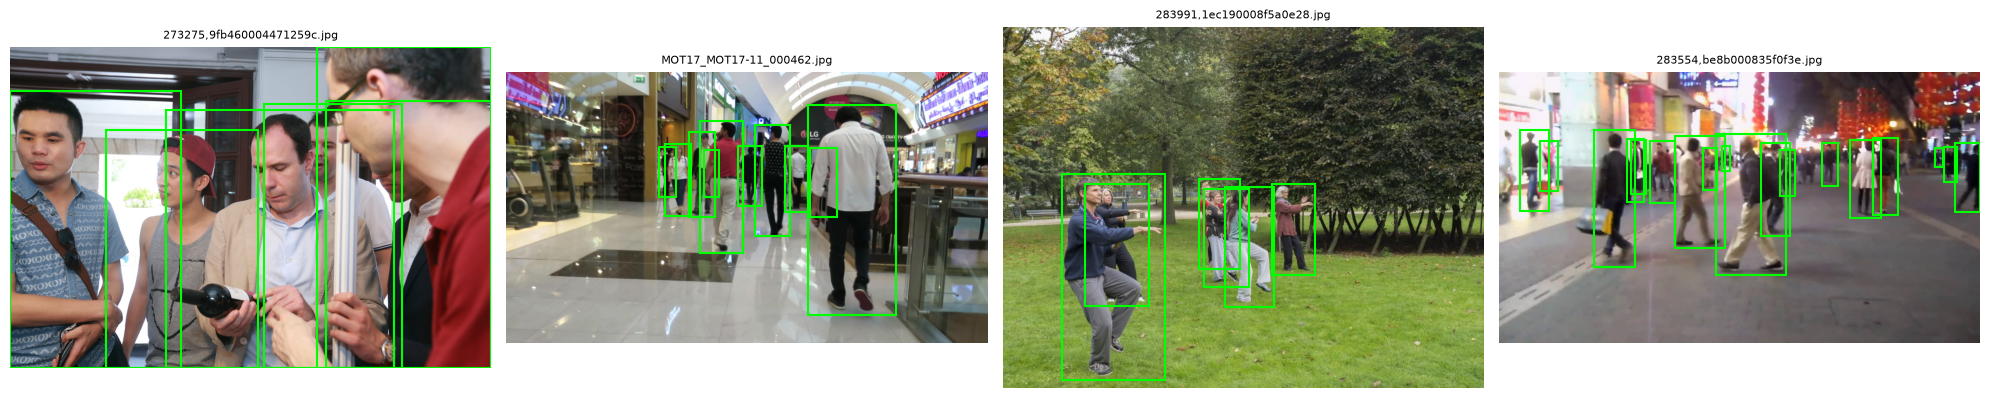

In [10]:
import random
import matplotlib.pyplot as plt

def show_sample(split="train", n=4):
    img_dir = DATASET_DIR / "images" / split
    lbl_dir = DATASET_DIR / "labels" / split
    imgs = random.sample(list(img_dir.glob("*.jpg")), k=min(n, len(list(img_dir.glob("*.jpg")))))

    fig, axes = plt.subplots(1, len(imgs), figsize=(5 * len(imgs), 5))
    if len(imgs) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, imgs):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            for line in lbl_path.read_text().splitlines():
                _, xc, yc, nw, nh = map(float, line.split())
                x1 = (xc - nw / 2) * w
                y1 = (yc - nh / 2) * h
                ax.add_patch(plt.Rectangle((x1, y1), nw * w, nh * h, fill=False, edgecolor="lime", linewidth=1.5))
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_sample("train", n=4)


## 8. Train YOLO, auto-extending until it hits the accuracy target

Trains for `EPOCHS` first, checks val `mAP50` against `TARGET_MAP50`, and if it's not there yet, keeps fine-tuning from the best checkpoint in additional `EXTRA_EPOCHS_PER_ROUND`-epoch rounds (up to `MAX_TOTAL_EPOCHS` total) rather than silently stopping short of the goal.

In [ ]:
from ultralytics import YOLO

def train_round(model_path, epochs, run_name):
    m = YOLO(model_path)
    m.train(
        data=str(data_yaml_path),
        epochs=epochs,
        imgsz=IMG_SIZE,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        project=str(RUNS_DIR),
        name=run_name,
        patience=0,
        exist_ok=True,
        optimizer="AdamW",
        cos_lr=True,
        mosaic=1.0,
        close_mosaic=10,
        scale=0.5,
        mixup=0.1,
        copy_paste=0.3,
        fliplr=0.5,
        hsv_h=0.015, hsv_s=0.5, hsv_v=0.3,
    )
    weights = RUNS_DIR / run_name / "weights" / "best.pt"
    metrics = YOLO(weights).val(data=str(data_yaml_path), imgsz=IMG_SIZE, device=DEVICE, augment=True)
    return weights, float(metrics.box.map50)

# --- Round 1: the initial budget ---
round_num = 1
total_epochs = EPOCHS
run_name = RUN_NAME
best_weights, map50 = train_round(MODEL_NAME, EPOCHS, run_name)
print(f"[round {round_num}] total_epochs={total_epochs} mAP50={map50:.3f} (target {TARGET_MAP50:.2f})")

# --- Auto-extend: keep fine-tuning from best.pt until target hit or ceiling reached ---
while map50 < TARGET_MAP50 and total_epochs < MAX_TOTAL_EPOCHS:
    round_num += 1
    run_name = f"{RUN_NAME}_r{round_num}"
    next_epochs = min(EXTRA_EPOCHS_PER_ROUND, MAX_TOTAL_EPOCHS - total_epochs)
    best_weights, map50 = train_round(best_weights, next_epochs, run_name)
    total_epochs += next_epochs
    print(f"[round {round_num}] total_epochs={total_epochs} mAP50={map50:.3f} (target {TARGET_MAP50:.2f})")

if map50 >= TARGET_MAP50:
    print(f"\nTarget reached: mAP50={map50:.3f} after {total_epochs} total epochs.")
else:
    print(f"\nHit MAX_TOTAL_EPOCHS ({MAX_TOTAL_EPOCHS}) before reaching target. "
          f"Best so far: mAP50={map50:.3f}. Consider yolo26n.pt, more augmentation, "
          f"or cleaning up label noise if this plateaus across rounds.")

print(f"Final weights: {best_weights}")

WARNING ⚠️ Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at '/home/student-12/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.133 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GB10, 122508MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/student-12/Desktop/crowddt/models/crowdhuman/yolo_person_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0

## 9. Final validation report

In [ ]:
trained_model = YOLO(best_weights)
metrics = trained_model.val(data=str(data_yaml_path), imgsz=IMG_SIZE, device=DEVICE, augment=True)
print(f"mAP50:    {metrics.box.map50:.3f}  (target: {TARGET_MAP50:.2f})")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")

### Other levers if you need more accuracy after this run

- **Raise the CrowdHuman visibility threshold**: in the conversion cell, `extra.get("ignore", 0) == 1` boxes are already dropped; you can go further and drop boxes below a visibility ratio (CrowdHuman also ships a `vbox`/`hbox` you can compare against `fbox`) if near-fully-occluded boxes are adding label noise rather than useful signal.
- **Go up a model scale** (`yolo26l.pt` / `yolo26x.pt`) if training time/VRAM allow — this is usually the single biggest accuracy lever after resolution.
- **Test-time augmentation at inference**, not just validation: `model.predict(..., augment=True)` (also supported by `.track()`) trades some speed for a modest accuracy bump on your actual video.
- **Fine-tune on your own footage**: CrowdHuman + MOT17 generalize well, but if your target video has a distinct camera angle/lighting/crowd density, labeling even a few hundred frames of your *actual* footage and fine-tuning `best.pt` on it for a short run will usually beat any amount of extra epochs on the public datasets.
